<a href="https://colab.research.google.com/github/Kellen0323/SlowLearner/blob/main/SAM3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!python --version

Python 3.12.13


In [2]:
!pip install torch==2.10.0 torchvision --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128


In [3]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e .

fatal: destination path 'sam3' already exists and is not an empty directory.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15720 sha256=c8663f234c4b6a27f958c1f17afa1f02807d03846b1a1f366cd2c63b74d39718
  Stored in directory: /tmp/pip-ephem-wheel-cache-9p3dkb_b/wheels/7c/90/be/80339bb9db8655024d6c9501da4e5efc6abbda4c897f5a6c43
Successfully built sam3
  Attempting uninstall: sam3
    Found existing installation: sam3 0.1.0
    Uninstalling sam3-0.1.0:
      Successfully uninstalled sam3-0.1.0


In [4]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? [y/N]: ㅛ
Error: invalid input
Add token as git credential? [y/N]: y
Token is valid (permission: write).
The token `kellen0323` has been saved to /root/.cache/huggingface/stored_tokens
Cannot authenticate through git-credential as no helper is de

In [6]:
from transformers import Sam3VideoModel, Sam3VideoProcessor
import torch

model = Sam3VideoModel.from_pretrained("facebook/sam3", device_map="auto")
processor = Sam3VideoProcessor.from_pretrained("facebook/sam3")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

In [8]:
!pip install av

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 17.2 MB/s eta 0:00:00


In [9]:
from transformers.video_utils import load_video
video_url = "https://huggingface.co/datasets/hf-internal-testing/sam2-fixtures/resolve/main/bedroom.mp4"
video_frames, _ = load_video(video_url)

In [11]:
inference_session = processor.init_video_session(
    video=video_frames,
    inference_device=device,
    processing_device="cpu",
    video_storage_device="cpu",
)

In [12]:
text = "person"
inference_session = processor.add_text_prompt(
    inference_session=inference_session,
    text=text,
)

In [13]:
# Process all frames in the video
outputs_per_frame = {}
# Pass show_progress_bar=True to display a tqdm progress bar.
for model_outputs in model.propagate_in_video_iterator(
    inference_session=inference_session, max_frame_num_to_track=50
):
    processed_outputs = processor.postprocess_outputs(inference_session, model_outputs)
    outputs_per_frame[model_outputs.frame_idx] = processed_outputs

print(f"Processed {len(outputs_per_frame)} frames")
# Processed 51 frames

# Access results for a specific frame
frame_0_outputs = outputs_per_frame[0]
print(f"Detected {len(frame_0_outputs['object_ids'])} objects")
print(f"Object IDs: {frame_0_outputs['object_ids'].tolist()}")
print(f"Scores: {frame_0_outputs['scores'].tolist()}")
print(f"Boxes shape (XYXY format, absolute coordinates): {frame_0_outputs['boxes'].shape}")
print(f"Masks shape: {frame_0_outputs['masks'].shape}")

[transformers] kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.


Processed 51 frames
Detected 2 objects
Object IDs: [0, 1]
Scores: [0.9686467051506042, 0.9736112356185913]
Boxes shape (XYXY format, absolute coordinates): torch.Size([2, 4])
Masks shape: torch.Size([2, 540, 960])


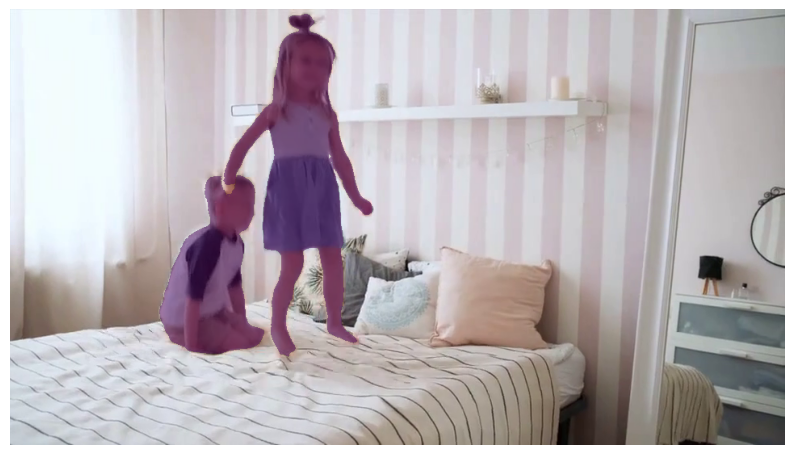

In [15]:
import matplotlib.pyplot as plt
import numpy as np

frame_idx = 10

frame = video_frames[frame_idx]
result = outputs_per_frame[frame_idx]

masks = result["masks"]

plt.figure(figsize=(10, 10))
plt.imshow(frame)

for mask in masks:
    mask = mask.cpu().numpy()

    plt.imshow(
        np.ma.masked_where(mask == 0, mask),
        alpha=0.5
    )

plt.axis("off")
plt.show()

In [16]:
import cv2
import numpy as np

height, width = video_frames[0].shape[:2]

writer = cv2.VideoWriter(
    "sam3_result.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    30,
    (width, height)
)

for frame_idx in sorted(outputs_per_frame.keys()):

    frame = video_frames[frame_idx].copy()

    result = outputs_per_frame[frame_idx]

    for mask in result["masks"]:
        mask = mask.cpu().numpy().astype(bool)

        frame[mask] = (
            0.5 * frame[mask] +
            0.5 * np.array([255, 0, 0])
        ).astype(np.uint8)

    writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

writer.release()